In [1]:
import mitgcm_assim.cost as cost

# Read all costfunction* files in current directory
ds_sep = cost.read_costfunction('/data/SO3/edavenport/tpose6/sep2012/run_ad_fixed_UVsigma/')
ds_nov = cost.read_costfunction('/data/SO3/edavenport/tpose6/nov2012/run_ad_fixed_UVsigma/')
ds_jan = cost.read_costfunction('/data/SO3/edavenport/tpose6/jan2013/run_ad/')
ds_mar = cost.read_costfunction('/data/SO3/edavenport/tpose6/mar2013/run_ad/')

In [2]:
# Identify the coordinate values that start with 'xx'
to_drop = [val for val in ds_mar.dataset.values if str(val).startswith('xx')]

# Drop those specific coordinates
ds_mar = ds_mar.drop_sel(dataset=to_drop)
ds_sep = ds_sep.drop_sel(dataset=to_drop)
ds_nov = ds_nov.drop_sel(dataset=to_drop)
ds_jan = ds_jan.drop_sel(dataset=to_drop)

# 1. Create a mask: True for anything that does NOT contain "GLD"
mask = ~ds_mar.dataset.str.contains("GLD")
# 2. Apply the mask to the dataset
ds_mar = ds_mar.sel(dataset=mask)
mask = ~ds_sep.dataset.str.contains("GLD")
ds_sep = ds_sep.sel(dataset=mask)
mask = ~ds_nov.dataset.str.contains("GLD")
ds_nov = ds_nov.sel(dataset=mask)
mask = ~ds_jan.dataset.str.contains("GLD")
ds_jan = ds_jan.sel(dataset=mask)

ds_mar = ds_mar.drop_sel(dataset='fc')
ds_sep = ds_sep.drop_sel(dataset='fc')
ds_nov = ds_nov.drop_sel(dataset='fc')
ds_jan = ds_jan.drop_sel(dataset='fc')

# Drop MDT (geoid reference), but keep sshv4-gfo (CryoSat)
ds_mar = ds_mar.drop_sel(dataset=['sshv4-mdt'])
ds_sep = ds_sep.drop_sel(dataset=['sshv4-mdt'])
ds_nov = ds_nov.drop_sel(dataset=['sshv4-mdt'])
ds_jan = ds_jan.drop_sel(dataset=['sshv4-mdt'])

In [3]:
import re

# 1. Define a function to strip the year (e.g., _2013_)
def remove_year(name):
    # This looks for an underscore, 4 digits, and another underscore
    return re.sub(r'_\d{4}_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_year(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

def remove_v2(name):
    return re.sub(r'_v2_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_v2(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

def remove_ED(name):
    return re.sub(r'_ED_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_ED(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

In [4]:
rename_map = {
    'TAO_WO_CTD_daily_prof_S': 'TAO/TRITON S',
    'TAO_WO_CTD_daily_prof_T': 'TAO/TRITON T',
    'TAO_WO_ADCP_prof_U': 'TAO/TRITON ADCP U',
    'TAO_WO_ADCP_prof_V': 'TAO/TRITON ADCP V',
    'TAO_WO_CUR_prof_U': 'TAO/TRITON CUR U',
    'TAO_WO_CUR_prof_V': 'TAO/TRITON CUR V',
    'USGO_TP_PFL_D_w_prof_S': 'Argo S',
    'USGO_TP_PFL_D_w_prof_T': 'Argo T',
    'WOD_TP_XBT_w_prof_T': 'WOD XBT T',
    'HDO_TP_CTD_w_prof_S': 'CTD S',
    'HDO_TP_CTD_w_prof_T': 'CTD T',
    'SIO_TP_XBT_w_prof_T': 'SIO XBT T',
    'sst-MW': 'SST',
    'sshv4-tp': 'Jason SSH',
    'sshv4-gfo': 'CryoSat SSH',
    'NODC_TP_MRB_w_prof_S':'TAO/TRITON S',
    'NODC_TP_MRB_w_prof_T':'TAO/TRITON T',
}
ds_mar = ds_mar.assign_coords(
    dataset=ds_mar.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_jan = ds_jan.assign_coords(
    dataset=ds_jan.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_sep = ds_sep.assign_coords(
    dataset=ds_sep.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_nov = ds_nov.assign_coords(
    dataset=ds_nov.dataset.to_index().map(lambda x: rename_map.get(x, x))
)

### Corrected SSH observation counts

The `n_obs` values read from the cost function files are incorrect for the SSH datasets. The table below gives the true counts of non-NaN observations per 4-month window, computed in `total_obs.ipynb` by reading the full RADS binary files and replacing the fill value (−9999) before counting.

| Period            | Jason SSH | CryoSat SSH | Jason % | CryoSat % |
|-------------------|----------:|------------:|--------:|----------:|
| Sep–Dec 2012      |   992,377 |     456,152 |   68.5% |     31.5% |
| Nov 2012–Feb 2013 |   740,827 |     447,784 |   62.3% |     37.7% |
| Jan–Apr 2013      |   455,115 |     443,459 |   50.6% |     49.4% |
| Mar–Jun 2013      |   465,152 |     460,734 |   50.2% |     49.8% |

In [5]:
# Override n_obs for Jason SSH and CryoSat SSH with values from total_obs.ipynb
# (cost function files store incorrect n_obs for these datasets)
n_obs_corrections = {
    'Sep': {'Jason SSH': 992377,  'CryoSat SSH': 456152},
    'Nov': {'Jason SSH': 740827,  'CryoSat SSH': 447784},
    'Jan': {'Jason SSH': 455115,  'CryoSat SSH': 443459},
    'Mar': {'Jason SSH': 465152,  'CryoSat SSH': 460734},
}
window_ds = {'Sep': ds_sep, 'Nov': ds_nov, 'Jan': ds_jan, 'Mar': ds_mar}
for window, corrections in n_obs_corrections.items():
    for sat_name, count in corrections.items():
        window_ds[window]['n_obs'].loc[dict(dataset=sat_name)] = count

In [6]:
ds_mar = ds_mar.drop_sel(dataset=['CryoSat SSH'])
ds_sep = ds_sep.drop_sel(dataset=['CryoSat SSH'])
ds_nov = ds_nov.drop_sel(dataset=['CryoSat SSH'])
ds_jan = ds_jan.drop_sel(dataset=['CryoSat SSH'])

In [7]:
# Multipliers applied only to the raw cost for visualization (e.g., to bring SST onto
# the same scale as other datasets in the log-scale bar chart). These are NOT applied
# before computing normalized cost (cost / n_obs), which must reflect the true values.
cost_multipliers = {
    'SST': 0.01,
    'SIO XBT T': 2,
    'WOD XBT T': 2,
    'CTD T': 2,
    'CTD S': 2,
    'Argo T': 2,
    'Argo S': 2,
}

In [8]:
import matplotlib.colors as mcolors

# Define your groups and which datasets belong to each
color_groups = {
    'Satellite':  ['SST', 'Jason SSH'],
    # 'SSH':        ['Jason SSH', 'CryoSat SSH'],
    # 'SSH':        ['Jason SSH'],
    'XBT':        ['SIO XBT T', 'WOD XBT T'],
    'TAO/TRITON': ['TAO/TRITON ADCP U', 'TAO/TRITON ADCP V', 'TAO/TRITON T', 'TAO/TRITON S', 'TAO/TRITON CUR U', 'TAO/TRITON CUR V'],
    'Argo':       ['Argo T', 'Argo S'],
    'CTD':        ['CTD T', 'CTD S'],
}

# Define a base colormap per group
group_cmaps = {
    'Satellite':  'Reds',
    # 'SSH':        'Oranges',
    'XBT':        'Oranges',
    'TAO/TRITON': 'Greens',
    'Argo':       'Blues',
    'CTD':        'Purples',
}

/tmp/ipykernel_854574/2446548715.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(group_cmaps[group], len(members) + 2)  # +2 avoids too-light ends


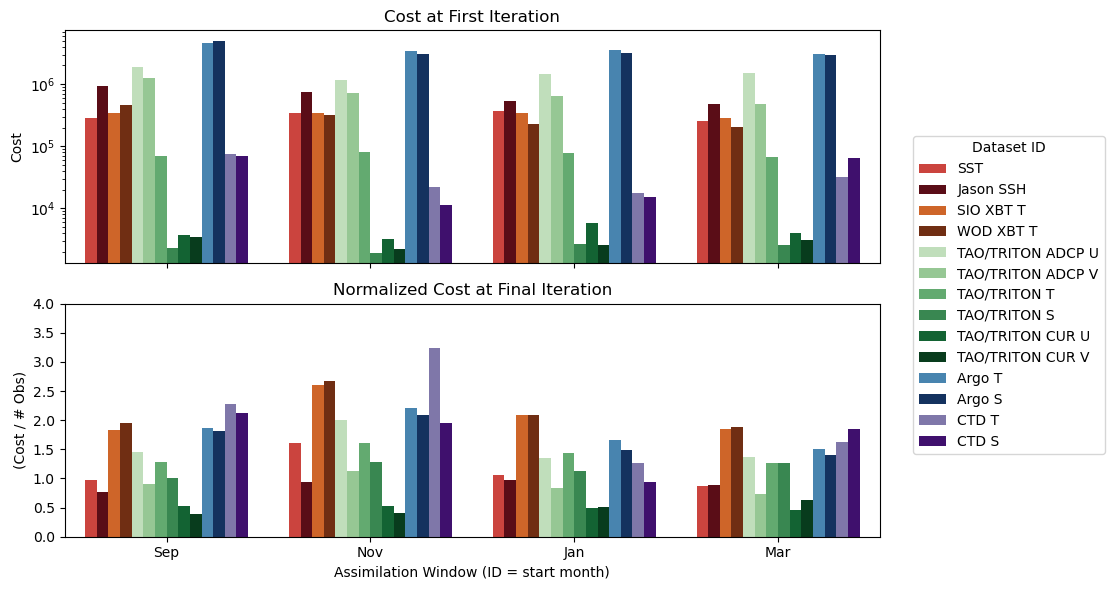

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list_cost = []
df_list_norm = []

for label, ds in datasets.items():
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=0)
    else:
        ds_subset = ds

    df_cost = ds_subset[['cost']].to_dataframe().reset_index()
    # Apply display-only multipliers to raw cost (does not affect normalized cost)
    df_cost['cost'] = df_cost['cost'] * df_cost['dataset'].map(cost_multipliers).fillna(1.0)
    df_cost['Group'] = label
    df_list_cost.append(df_cost)

    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds

    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    df_norm = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df_norm['Group'] = label
    df_list_norm.append(df_norm)

df_cost_total = pd.concat(df_list_cost, ignore_index=True)
df_norm_total = pd.concat(df_list_norm, ignore_index=True)

# Lock x-axis order, sort hue alphabetically within each group
group_order = ['Sep', 'Nov', 'Jan', 'Mar']

df_cost_total['Group'] = pd.Categorical(df_cost_total['Group'], categories=group_order, ordered=True)
df_norm_total['Group'] = pd.Categorical(df_norm_total['Group'], categories=group_order, ordered=True)

df_cost_total = df_cost_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
df_norm_total = df_norm_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
hue_order = sorted(df_cost_total['dataset'].unique())

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Build the palette: map each dataset -> a specific color
palette = {}
for group, members in color_groups.items():
    cmap = plt.cm.get_cmap(group_cmaps[group], len(members) + 2)  # +2 avoids too-light ends
    for i, dataset in enumerate(members):
        palette[dataset] = mcolors.to_hex(cmap(i + 2))  # skip the lightest shades

hue_order = [ds for members in color_groups.values() for ds in members]  # preserves group ordering

sns.barplot(data=df_cost_total, x='Group', y='cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_top, legend=False)
ax_top.set_yscale('log')
ax_top.set_title('Cost at First Iteration')
ax_top.set_xlabel('')
ax_top.set_ylabel('Cost')

sns.barplot(data=df_norm_total, x='Group', y='norm_cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_bot, legend=True)
ax_bot.set_title('Normalized Cost at Final Iteration')
ax_bot.set_xlabel('Assimilation Window (ID = start month)')
ax_bot.set_ylabel('(Cost / # Obs)')
ax_bot.set_ylim(0, 4)

handles, labels = ax_bot.get_legend_handles_labels()
ax_bot.get_legend().remove()
fig.legend(handles, labels, title='Dataset ID',
           bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

plt.tight_layout()
fig.savefig('assimilation_results/normalized_cost/cost_normcost_firstIter.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_854574/1392221368.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(group_cmaps[group], len(members) + 2)  # +2 avoids too-light ends


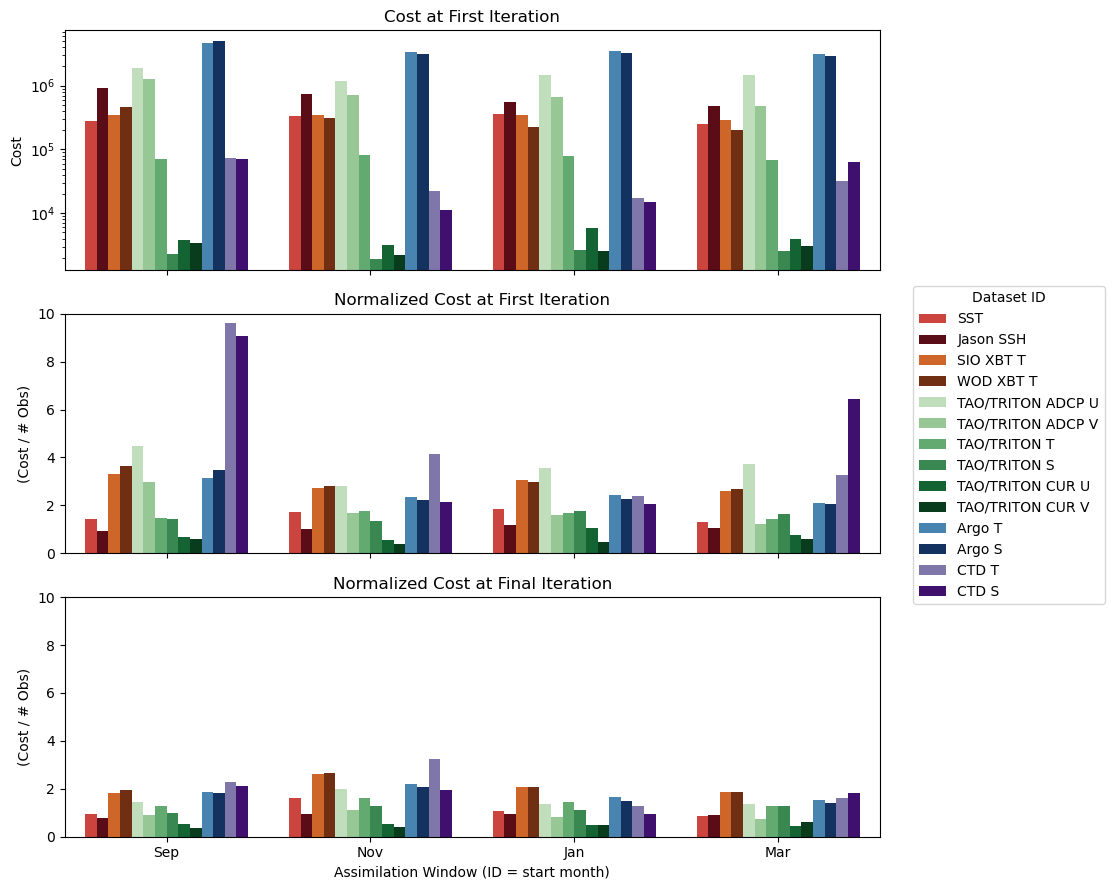

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list_cost = []
df_list_norm_iter0 = []
df_list_norm = []

for label, ds in datasets.items():
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=0)
    else:
        ds_subset = ds

    df_cost = ds_subset[['cost']].to_dataframe().reset_index()
    # Apply display-only multipliers to raw cost (does not affect normalized cost)
    df_cost['cost'] = df_cost['cost'] * df_cost['dataset'].map(cost_multipliers).fillna(1.0)
    df_cost['Group'] = label
    df_list_cost.append(df_cost)

    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    df_norm_iter0 = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df_norm_iter0['Group'] = label
    df_list_norm_iter0.append(df_norm_iter0)

    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds

    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    df_norm = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df_norm['Group'] = label
    df_list_norm.append(df_norm)

df_cost_total = pd.concat(df_list_cost, ignore_index=True)
df_norm_iter0 = pd.concat(df_list_norm_iter0, ignore_index=True)
df_norm_total = pd.concat(df_list_norm, ignore_index=True)

# Lock x-axis order, sort hue alphabetically within each group
group_order = ['Sep', 'Nov', 'Jan', 'Mar']

df_cost_total['Group'] = pd.Categorical(df_cost_total['Group'], categories=group_order, ordered=True)
df_norm_iter0['Group'] = pd.Categorical(df_norm_iter0['Group'], categories=group_order, ordered=True)
df_norm_total['Group'] = pd.Categorical(df_norm_total['Group'], categories=group_order, ordered=True)

df_cost_total = df_cost_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
df_norm_iter0 = df_norm_iter0.sort_values(['Group', 'dataset']).reset_index(drop=True)
df_norm_total = df_norm_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
hue_order = sorted(df_cost_total['dataset'].unique())

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Build the palette: map each dataset -> a specific color
palette = {}
for group, members in color_groups.items():
    cmap = plt.cm.get_cmap(group_cmaps[group], len(members) + 2)  # +2 avoids too-light ends
    for i, dataset in enumerate(members):
        palette[dataset] = mcolors.to_hex(cmap(i + 2))  # skip the lightest shades

hue_order = [ds for members in color_groups.values() for ds in members]  # preserves group ordering

sns.barplot(data=df_cost_total, x='Group', y='cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_top, legend=False)
ax_top.set_yscale('log')
ax_top.set_title('Cost at First Iteration')
ax_top.set_xlabel('')
ax_top.set_ylabel('Cost')

sns.barplot(data=df_norm_iter0, x='Group', y='norm_cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_mid, legend=False)
ax_mid.set_title('Normalized Cost at First Iteration')
ax_mid.set_xlabel('')
ax_mid.set_ylabel('(Cost / # Obs)')
ax_mid.set_ylim(0, 10)

sns.barplot(data=df_norm_total, x='Group', y='norm_cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_bot, legend=True)
ax_bot.set_title('Normalized Cost at Final Iteration')
ax_bot.set_xlabel('Assimilation Window (ID = start month)')
ax_bot.set_ylabel('(Cost / # Obs)')
ax_bot.set_ylim(0, 10)

handles, labels = ax_bot.get_legend_handles_labels()
ax_bot.get_legend().remove()
fig.legend(handles, labels, title='Dataset ID',
           bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

plt.tight_layout()
fig.savefig('assimilation_results/normalized_cost/cost_normcost_3panel.png', bbox_inches='tight')
plt.show()

### Controls

In [11]:
import mitgcm_assim.cost as cost
# Read all costfunction* files in current directory
ds_sep = cost.read_costfunction('/data/SO3/edavenport/tpose6/sep2012/run_ad_fixed_UVsigma/')
ds_nov = cost.read_costfunction('/data/SO3/edavenport/tpose6/nov2012/run_ad_fixed_UVsigma/')
ds_jan = cost.read_costfunction('/data/SO3/edavenport/tpose6/jan2013/run_ad/')
ds_mar = cost.read_costfunction('/data/SO3/edavenport/tpose6/mar2013/run_ad/')

to_keep = [val for val in ds_mar.dataset.values if str(val).startswith('xx')]
ds_mar = ds_mar.sel(dataset=to_keep)
to_keep = [val for val in ds_sep.dataset.values if str(val).startswith('xx')]
ds_sep = ds_sep.sel(dataset=to_keep)
to_keep = [val for val in ds_nov.dataset.values if str(val).startswith('xx')]
ds_nov = ds_nov.sel(dataset=to_keep)
to_keep = [val for val in ds_jan.dataset.values if str(val).startswith('xx')]
ds_jan = ds_jan.sel(dataset=to_keep)

In [12]:
ds_mar.dataset

<xarray.DataArray 'dataset' (dataset: 11)> Size: 1kB
array(['xx_aqh', 'xx_atemp', 'xx_lwdown', 'xx_precip', 'xx_salt', 'xx_swdown',
       'xx_theta', 'xx_uvel', 'xx_uwind', 'xx_vvel', 'xx_vwind'], dtype='<U31')
Coordinates:
  * dataset  (dataset) <U31 1kB 'xx_aqh' 'xx_atemp' ... 'xx_vvel' 'xx_vwind'

In [13]:
rename_map = {
    'xx_aqh': 'Atmos. Humidity',
    'xx_atemp': 'Atmos. Temp.',
    'xx_lwdown': 'Downward Longwave',
    'xx_precip': 'Precipitation',
    'xx_swdown': 'Downward Shortwave',
    'xx_uwind': 'Zonal Wind',
    'xx_vwind': 'Meridional Wind',
    'xx_theta': 'Initial T',
    'xx_salt': 'Initial S',
    'xx_uvel': 'Initial U',
    'xx_vvel': 'Initial V',
}
ds_mar = ds_mar.assign_coords(
    dataset=ds_mar.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_jan = ds_jan.assign_coords(
    dataset=ds_jan.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_sep = ds_sep.assign_coords(
    dataset=ds_sep.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_nov = ds_nov.assign_coords(
    dataset=ds_nov.dataset.to_index().map(lambda x: rename_map.get(x, x))
)

In [14]:
import matplotlib.colors as mcolors

# Define your groups and which datasets belong to each
color_groups = {
    'Atmos':  ['Atmos. Humidity','Atmos. Temp.','Precipitation'],
    'Radiation':       ['Downward Longwave', 'Downward Shortwave'],
    'Wind': ['Zonal Wind', 'Meridional Wind'],
    'Initial Hydro':       ['Initial T', 'Initial S'],
    'Initial Vel':       ['Initial U', 'Initial V'],
    # add more groups as needed
}

# Define a base colormap per group
group_cmaps = {
    'Atmos':  'Reds',
    'Radiation':        'Oranges',
    'Wind': 'Blues',
    'Initial Hydro':       'Greens',
    'Initial Vel':        'Purples',
    # add more as needed
}

/tmp/ipykernel_854574/3437288354.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(group_cmaps[group], len(members) + 2)  # +2 avoids too-light ends


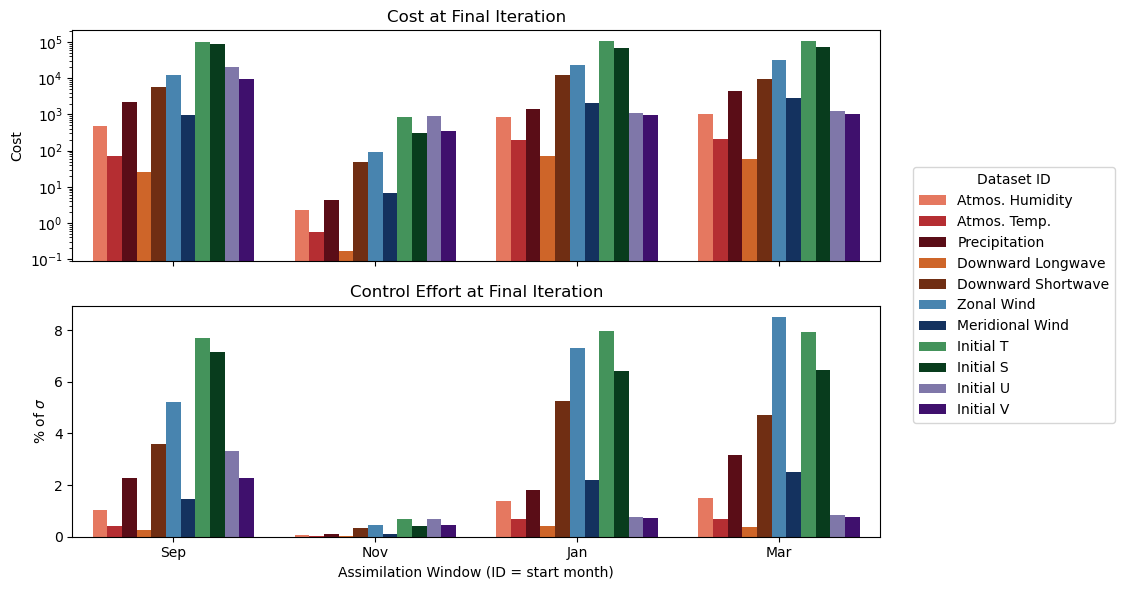

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list_cost = []
df_list_norm = []

for label, ds in datasets.items():
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds

    df_cost = ds_subset[['cost']].to_dataframe().reset_index()
    df_cost['Group'] = label
    df_list_cost.append(df_cost)

    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds

    ds_subset['norm_cost'] = np.sqrt(ds_subset['cost'] / ds_subset['n_obs'])*100
    df_norm = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df_norm['Group'] = label
    df_list_norm.append(df_norm)

df_cost_total = pd.concat(df_list_cost, ignore_index=True)
df_norm_total = pd.concat(df_list_norm, ignore_index=True)

# Lock x-axis order, sort hue alphabetically within each group
group_order = ['Sep', 'Nov', 'Jan', 'Mar']

df_cost_total['Group'] = pd.Categorical(df_cost_total['Group'], categories=group_order, ordered=True)
df_norm_total['Group'] = pd.Categorical(df_norm_total['Group'], categories=group_order, ordered=True)

df_cost_total = df_cost_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
df_norm_total = df_norm_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
hue_order = sorted(df_cost_total['dataset'].unique())

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Build the palette: map each dataset -> a specific color
palette = {}
for group, members in color_groups.items():
    cmap = plt.cm.get_cmap(group_cmaps[group], len(members) + 2)  # +2 avoids too-light ends
    for i, dataset in enumerate(members):
        palette[dataset] = mcolors.to_hex(cmap(i + 2))  # skip the lightest shades

hue_order = [ds for members in color_groups.values() for ds in members]  # preserves group ordering

sns.barplot(data=df_cost_total, x='Group', y='cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_top, legend=False)
ax_top.set_yscale('log')
ax_top.set_title('Cost at Final Iteration')
ax_top.set_xlabel('')
ax_top.set_ylabel('Cost')

sns.barplot(data=df_norm_total, x='Group', y='norm_cost', hue='dataset',
            hue_order=hue_order, palette=palette, ax=ax_bot, legend=True)
ax_bot.set_title('Control Effort at Final Iteration')
ax_bot.set_xlabel('Assimilation Window (ID = start month)')
ylabel = r'% of $\sigma$'
ax_bot.set_ylabel(ylabel)
# ax_bot.set_yscale('log')

handles, labels = ax_bot.get_legend_handles_labels()
ax_bot.get_legend().remove()
fig.legend(handles, labels, title='Dataset ID',
           bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

plt.tight_layout()
fig.savefig('assimilation_results/normalized_cost/cost_normcost_firstIter_controls.png', bbox_inches='tight')
plt.show()